In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [2]:
data = pd.read_csv(r'D:\Week1 Project\House price ped\house_data.csv')
data.head()

,square_feet,bedrooms,bathrooms,age,price
0,2000,3,2.0,10,450000
1,1500,2,1.0,5,350000
2,2500,4,3.0,15,500000
3,1200,2,1.0,3,320000
4,3000,4,3.0,20,580000


In [3]:
df = data

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   square_feet  25 non-null     int64  
 1   bedrooms     25 non-null     int64  
 2   bathrooms    25 non-null     float64
 3   age          25 non-null     int64  
 4   price        25 non-null     int64  
dtypes: float64(1), int64(4)
memory usage: 1.1 KB


In [5]:
df.shape

(25, 5)

In [6]:
df.describe()

,square_feet,bedrooms,bathrooms,age,price
count,25.000000,25.000000,25.000000,25.000000,25.000000
mean,2018.000000,3.040000,2.120000,10.200000,441000.000000
std,567.685359,0.789515,0.781025,6.144103,94196.160573
min,1200.000000,2.000000,1.000000,2.000000,300000.000000
25%,1500.000000,2.000000,1.500000,5.000000,350000.000000
50%,2000.000000,3.000000,2.000000,10.000000,450000.000000
75%,2500.000000,4.000000,3.000000,15.000000,510000.000000
max,3000.000000,4.000000,3.500000,22.000000,600000.000000


In [7]:
df.isnull().sum()

square_feet    0
bedrooms       0
bathrooms      0
age            0
price          0
dtype: int64

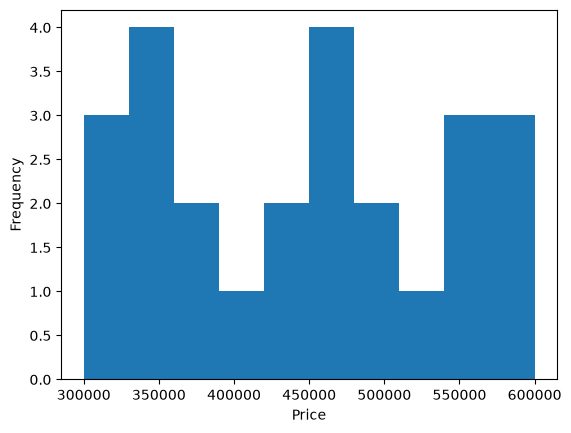

In [8]:
plt.hist(df['price'],bins=10)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

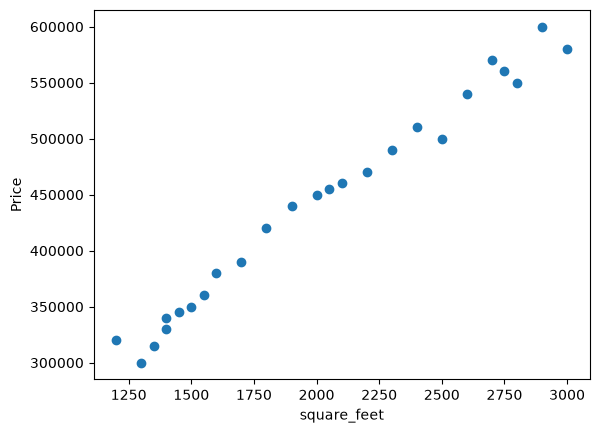

In [9]:
plt.scatter(df['square_feet'],df['price'])
plt.xlabel('square_feet')
plt.ylabel('Price')
plt.show()

In [10]:
df.corr()

,square_feet,bedrooms,bathrooms,age,price
square_feet,1.000000,0.932628,0.955828,0.989248,0.990984
bedrooms,0.932628,1.000000,0.937893,0.917363,0.935086
bathrooms,0.955828,0.937893,1.000000,0.949910,0.963940
age,0.989248,0.917363,0.949910,1.000000,0.989919
price,0.990984,0.935086,0.963940,0.989919,1.000000


In [11]:
# Features: square_feet, bedrooms, bathrooms, age
# Target: price

In [12]:
x = df[['square_feet','bedrooms','bathrooms','age']]
y = df['price']

In [13]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
model = LinearRegression()
model.fit(x_train,y_train)
for i,col in enumerate(x.columns):
    print(f'{col}:{model.coef_[i]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')

square_feet:82.51
bedrooms:4434.71
bathrooms:13520.54
age:5336.64
Intercept: 178990.50


In [15]:
y_pred = model.predict(x_test)

In [16]:
comparison = pd.DataFrame({'Actual':y_test,'Predicted':y_pred})
print(comparison.head())

    Actual      Predicted
8   550000  564392.422057
16  540000  537216.144411
0   450000  437732.058732
23  315000  323448.939359
11  300000  319323.191375


In [17]:
mse = mean_squared_error(y_test,y_pred)
print(f'MSE: {mse:.2f}')

rmse = np.sqrt(mse)
print(f'RMSE: {rmse:.2f}')

mae = mean_absolute_error(y_test,y_pred)
print(f'MAE: {mae:.2f}')

r2 = r2_score(y_test,y_pred)
print(f'R2 score: {r2:.2f}')

MSE: 162032869.75
RMSE: 12729.21
MAE: 11443.27
R2 score: 0.99


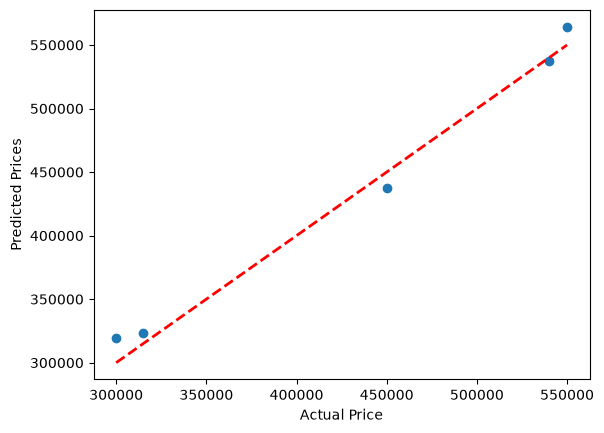

In [18]:
plt.scatter(y_test,y_pred)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--',lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Prices')
plt.show()

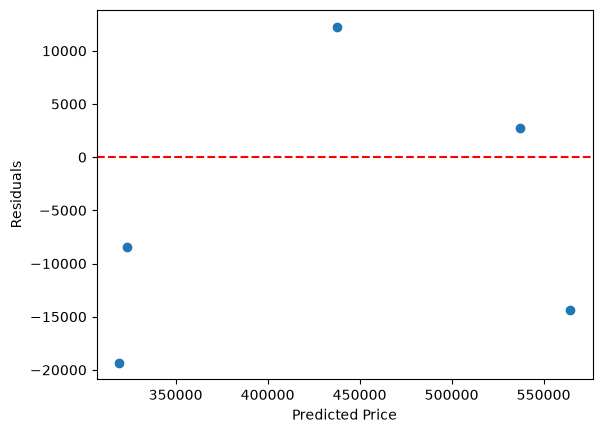

In [19]:
residuals = y_test - y_pred
plt.scatter(y_pred,residuals)
plt.axhline(y=0,color='r',linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.show()

In [20]:
new_house = np.array([[2000, 3, 2, 5]])
predicted_price = model.predict(new_house)
print(f"Predicted price: ${predicted_price[0]:,.2f}")

Predicted price: $411,048.84


c:\Users\khpra\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [22]:
print("\n" + "="*50)
print("MODEL SUMMARY")
print("="*50)
print(f'R2 score: {r2:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')


MODEL SUMMARY
R2 score: 0.99
RMSE: 12729.21
MAE: 11443.27
